In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import astropy.io.fits as fits
import astropy.units as u

In [3]:
# The code in this notebook smooths and downgrades the templates used in the
# External Linear Cleaning (ELC) process described in Nofi et al. (2025a), 
# https://arxiv.org/abs/2509.03718, to a common NSIDE = 128 and 1 degree resolution. 
# The resulting template maps are stored in the Templates/ directory.

In [4]:
# Note: WMAP MEM free-free is already at NSIDE = 128, 1 degree resolution

In [5]:
nside=128

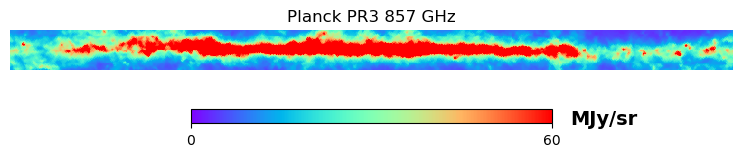

In [6]:
p857_map="HFI_SkyMap_857-field-Int_2048_R3.00_full.fits"
p857=hp.fitsfunc.read_map(p857_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_857x857.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p857_bl = tbdata['TEMPERATURE']
p857_ell = np.arange(0,len(p857_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p857_ell*(p857_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p857_bl
smth857_kernel = smth_kernel/smth_kernel[0] 

# Perform smoothing with hp.smoothing and 857 GHz beam window function
sm_r11_857 = hp.smoothing(p857, beam_window=smth857_kernel)

# Downgrade maps to NSIDE = 128
p857_dg = hp.ud_grade(sm_r11_857, nside)

hp.cartview(p857_dg, latra = [-10,10], min=0, max=60, title = 'Planck PR3 857 GHz', unit = 'MJy/sr',cmap='rainbow')

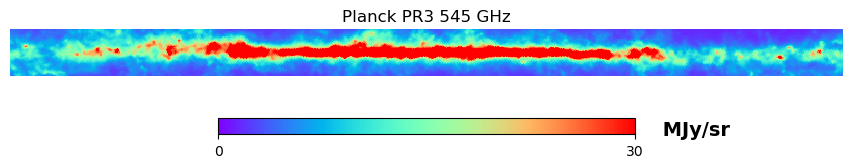

In [7]:
p545_map="HFI_SkyMap_545-field-Int_2048_R3.00_full.fits"
p545=hp.fitsfunc.read_map(p545_map,field=[0])

# Smooth maps to 1 degree
# Use Planck beam transfer function
fits_table_filename = 'BeamWf_HFI_R3.01/Bl_T_R3.01_fullsky_545x545.fits'
hdul = fits.open(fits_table_filename)
tbdata = hdul[1].data  
p545_bl = tbdata['TEMPERATURE']
p545_ell = np.arange(0,len(p545_bl))

# Compute 1 degree fwhm Gaussian winfunc wl_bl in amplitude
beam_sigma_rad = 1.0*np.pi/180.0/np.sqrt(8.*np.log(2.))
wl_bl = np.exp(-0.5*p545_ell*(p545_ell+1)*beam_sigma_rad**2.)

# Normalize to peak
smth_kernel = wl_bl/p545_bl
smth545_kernel = smth_kernel/smth_kernel[0]

# Perform smoothing with hp.smoothing and 545 GHz beam window function
sm_r11_545 = hp.smoothing(p545, beam_window=smth545_kernel)

# Downgrade maps to NSIDE = 128
p545_dg = hp.ud_grade(sm_r11_545, nside)

hp.cartview(p545_dg,min=0,max=30,latra=[-10,10],cmap='rainbow',title='Planck PR3 545 GHz', unit=' MJy/sr',margins=(0.01,0.02,0.01,0.01))

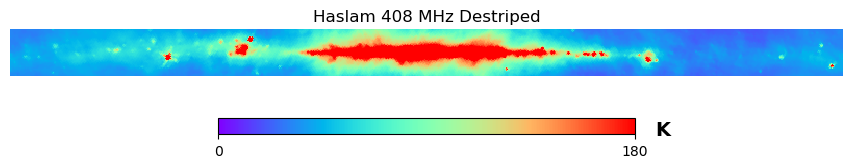

In [8]:
h408_map="haslam408_ds_Remazeilles2014.fits"
h408=hp.fitsfunc.read_map(h408_map,field=[0])

# Smooth maps to 1 degree from native resolution 
hbeam1 = 60 * u.arcmin
hbeam2 = 56 * u.arcmin
hfwhm = np.sqrt(hbeam1**2-hbeam2**2)
h408_smooth = hp.smoothing(h408, fwhm=hfwhm.to_value(u.radian))

# Downgrade to NSIDE = 128
h408_dg = hp.ud_grade(h408_smooth, nside)

hp.cartview(h408_dg,min=0,max=180,latra=[-10,10],cmap='rainbow',title='Haslam 408 MHz Destriped', unit='K',margins=(0.01,0.02,0.01,0.01))

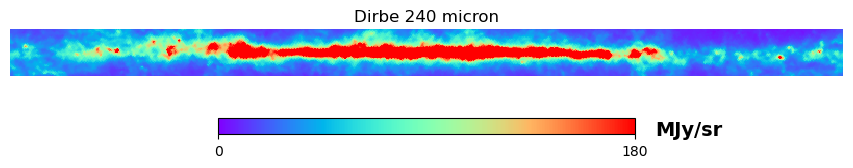

In [9]:
d10_map="DIRBE_ZSMA_10_1_256.fits"
d10=hp.fitsfunc.read_map(d10_map,field=[0])

# Smooth maps to 1 degree from native resolution 
dbeam1 = 1 * u.degree
dbeam2 = 0.7 * u.degree
dfwhm = np.sqrt(dbeam1**2-dbeam2**2)
d10_smooth = hp.smoothing(d10, fwhm=dfwhm.to_value(u.radian))

# Downgrade to NSIDE = 128
d10_dg = hp.ud_grade(d10_smooth, nside)

hp.cartview(d10_dg,min=0,max=180,latra=[-10,10],cmap='rainbow',title='Dirbe 240 micron', unit='MJy/sr',margins=(0.01,0.02,0.01,0.01))

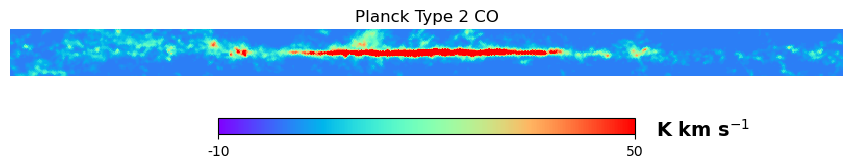

In [10]:
CO_p2_map="HFI_CompMap_CO-Type2_2048_R2.00.fits"
CO_p2=hp.fitsfunc.read_map(CO_p2_map,field=[0])

# Smooth maps to 1 degree from native resolution
cbeam1 = 60 * u.arcmin
cbeam2 = 15 * u.arcmin
cfwhm = np.sqrt(cbeam1**2-cbeam2**2)
CO_smooth = hp.smoothing(CO_p2, fwhm=cfwhm.to_value(u.radian))

# Downgrade to NSIDE = 128
CO_dg = hp.ud_grade(CO_smooth, nside)

# Implement <=0.5 threshold to reduce noise in template
CO_dg[CO_dg <= 0.5] = 0

hp.cartview(CO_dg, latra = [-10,10], min=-10, max=50, title = r'Planck Type 2 CO', unit = r'K km s$^{-1}$', cmap='rainbow',margins=(0.01,0.02,0.01,0.01))

In [12]:
hp.write_map("p857_dgsm_128_1deg.fits", p857_dg, overwrite=True)
hp.write_map("p545_dgsm_128_1deg.fits", p545_dg, overwrite=True)
hp.write_map("h408_dgsm_128_1deg.fits", h408_dg, overwrite=True)
hp.write_map("d240_dgsm_128_1deg.fits", d10_dg, overwrite=True)
hp.write_map("pCO_dgsm_128_1deg.fits", CO_dg, overwrite=True)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
